# **1. ETTh Dataset**

##<font color=blue>Prepare and load dataset</font>

---



In [ ]:
!curl -L -o ETTh1.csv https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2528k  100 2528k    0     0  4454k      0 --:--:-- --:--:-- --:--:-- 4460k


In [ ]:
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv("/content/ETTh1.csv")

In [ ]:
df.describe()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
std,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946
min,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000


| Field | date | HUFL | HULL | MUFL | MULL | LUFL | LULL | OT |
| :----: | :----: | :----: | :----: | :----: | :----: | :----: | :----: | :----: |
| Description | The recorded **date** |**H**igh **U**se**F**ul **L**oad | **H**igh **U**se**L**ess **L**oad | **M**iddle **U**se**F**ul **L**oad | **M**iddle **U**se**L**ess **L**oad | **L**ow **U**se**F**ul **L**oad | **L**ow **U**se**L**ess **L**oad | **O**il **T**emperature (target) |

In [ ]:
df['date'] = pd.to_datetime(df['date'])


####<font color='blue'>**Line Chart**</font>

---

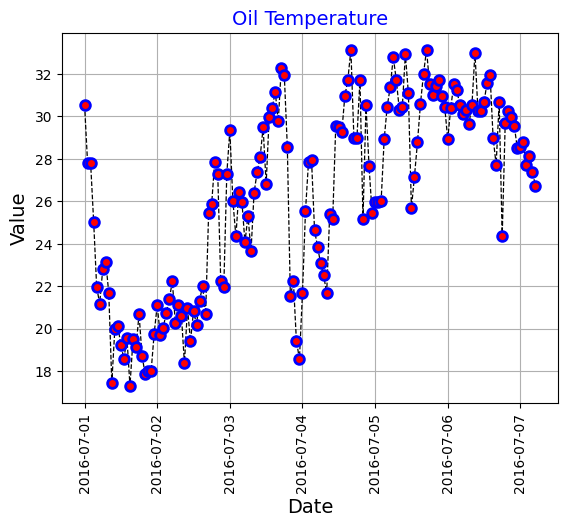

In [ ]:
# We want to determine which time has the highest OT (oil temperature)
# Use single plot chart

# Matplotlib
plt.plot(df.date[0:150], df.OT[0:150], marker = 'o', color = 'black',
         linewidth = 0.9, linestyle = '--',
         markeredgecolor = 'blue',
         markeredgewidth = '2.0',
         markerfacecolor = 'red', markersize = 7.0)
plt.title('Oil Temperature', color = 'Blue', size = 14)
plt.xlabel('Date', size = 14)
plt.ylabel('Value', size = 14)
plt.style.use('fivethirtyeight')
plt.grid(True)
plt.xticks(rotation = 90)
plt.show()

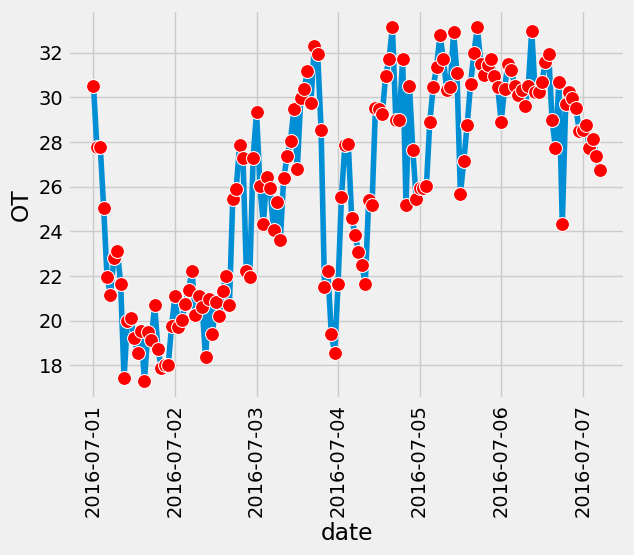

In [ ]:
# Seaborn library
sns.lineplot(data=df, x = df.date[0:150], y = df.OT[0:150], marker="o",
             markersize = 10, markerfacecolor = 'red')
plt.xticks(rotation = 90);

In [ ]:
# Plotly library
fig = px.line(df, x = df.date[0:150], y = df.OT[0:150],
              title='Oil Temperature', markers=True)
fig.update_layout(
    xaxis_title="Date", yaxis_title="Value"
)

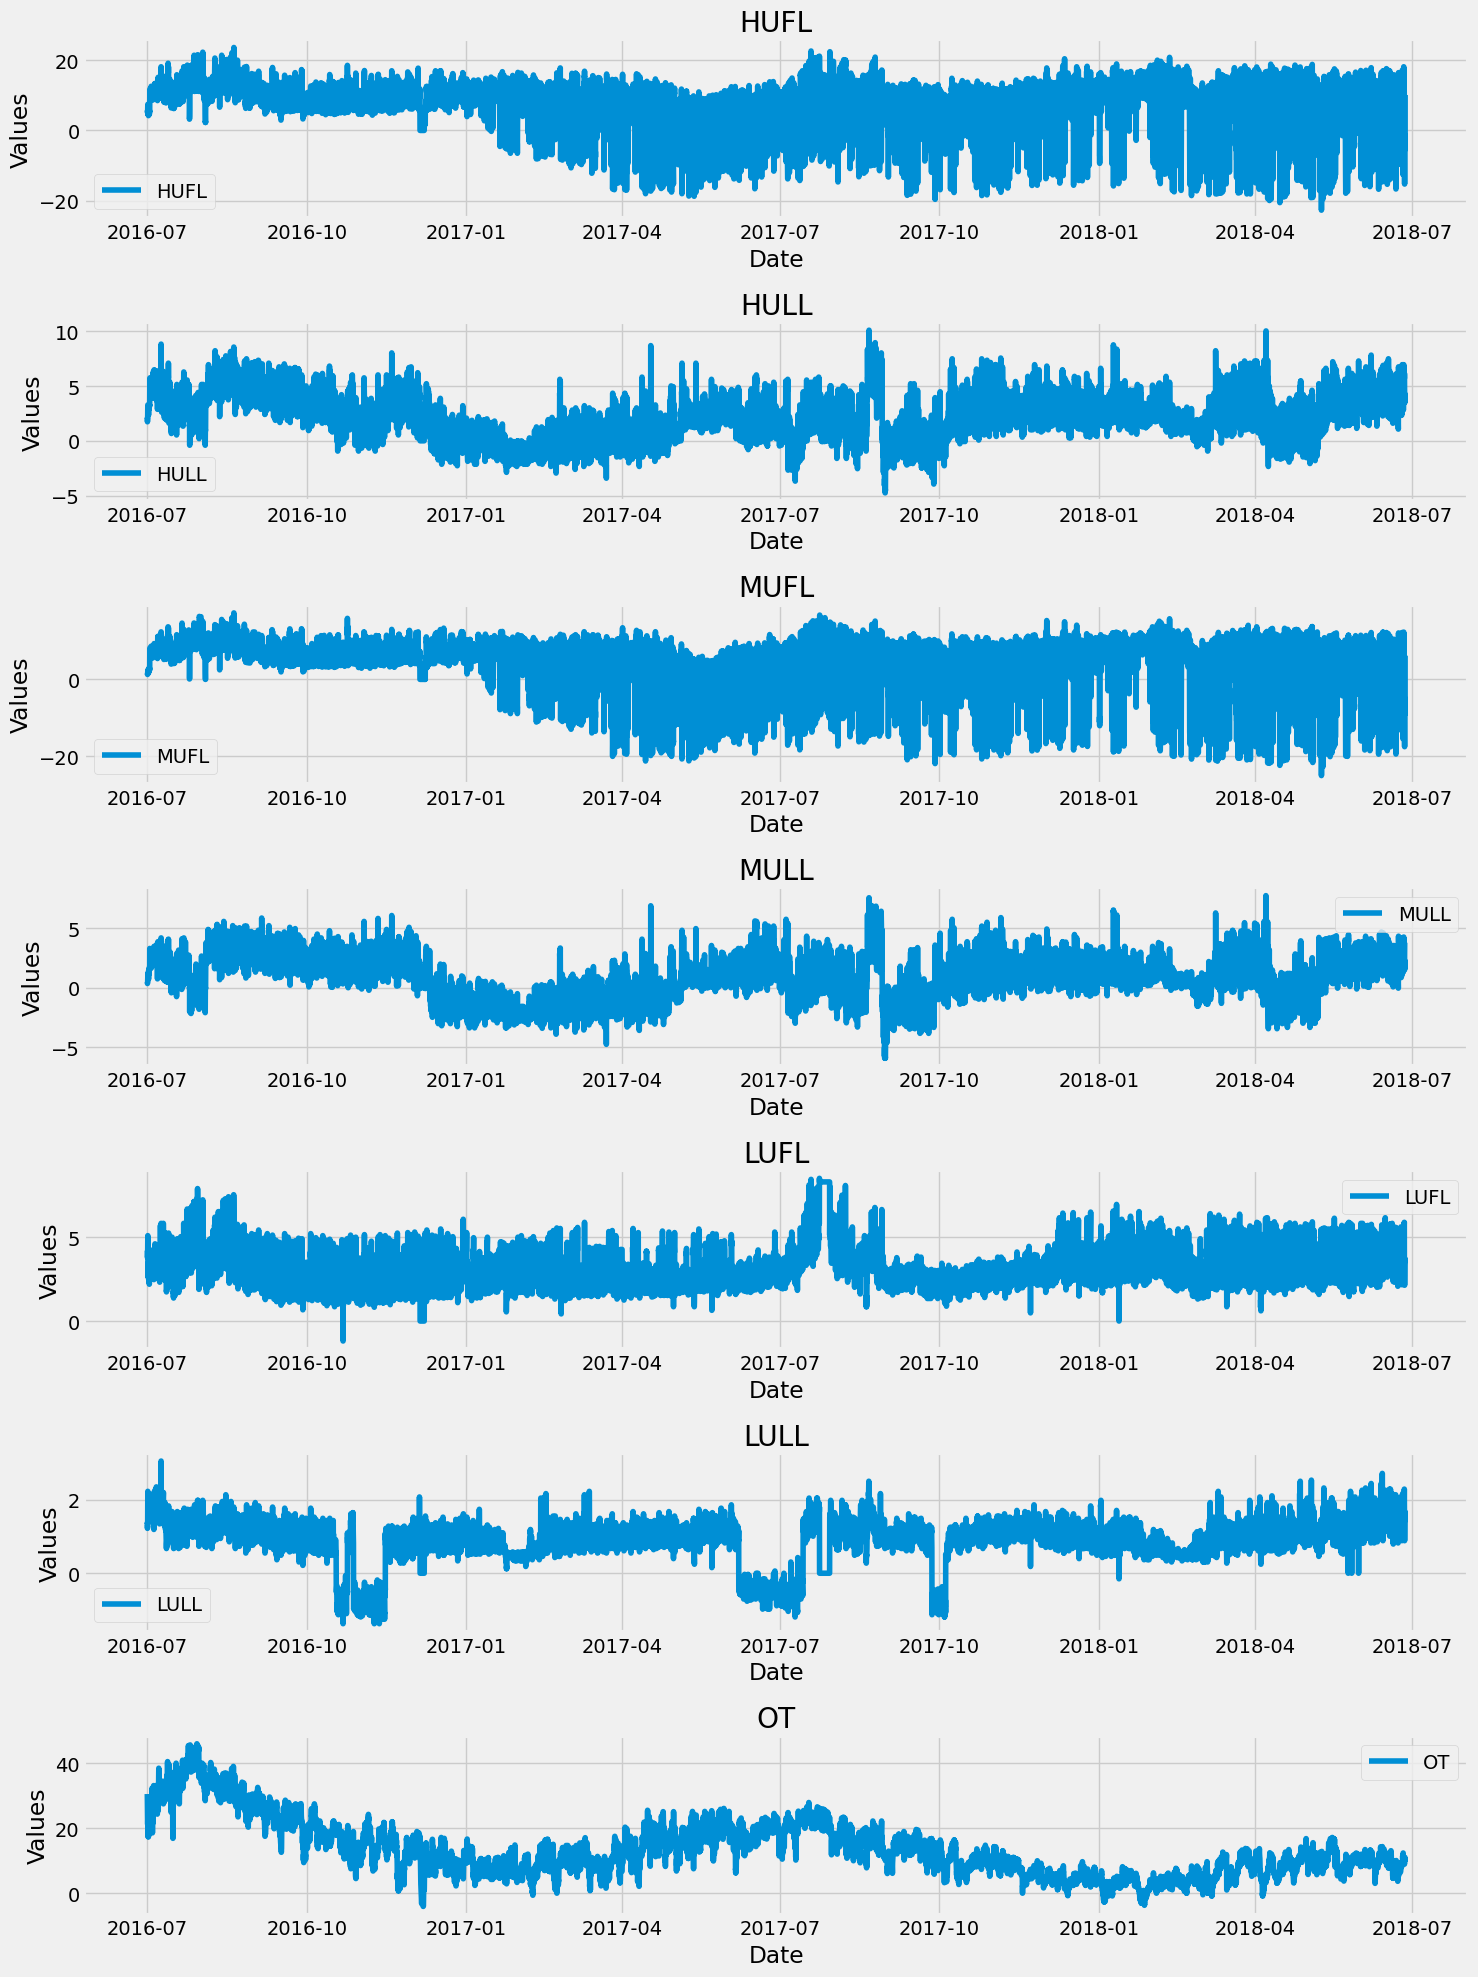

In [ ]:
# Multiple Plot Line Chart
# Setting the figure size and layout
fig, ax = plt.subplots(nrows = 7, ncols = 1, figsize = (15, 20))

# Plotting line charts for each variable except 'date'
for i, column in enumerate(df.columns[1:]):
    ax[i].plot(df['date'], df[column], label=column)
    ax[i].set_title(column)
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Values')
    ax[i].legend()

# Adjust layout for better scaling
plt.tight_layout()

# Display the plots
plt.show()

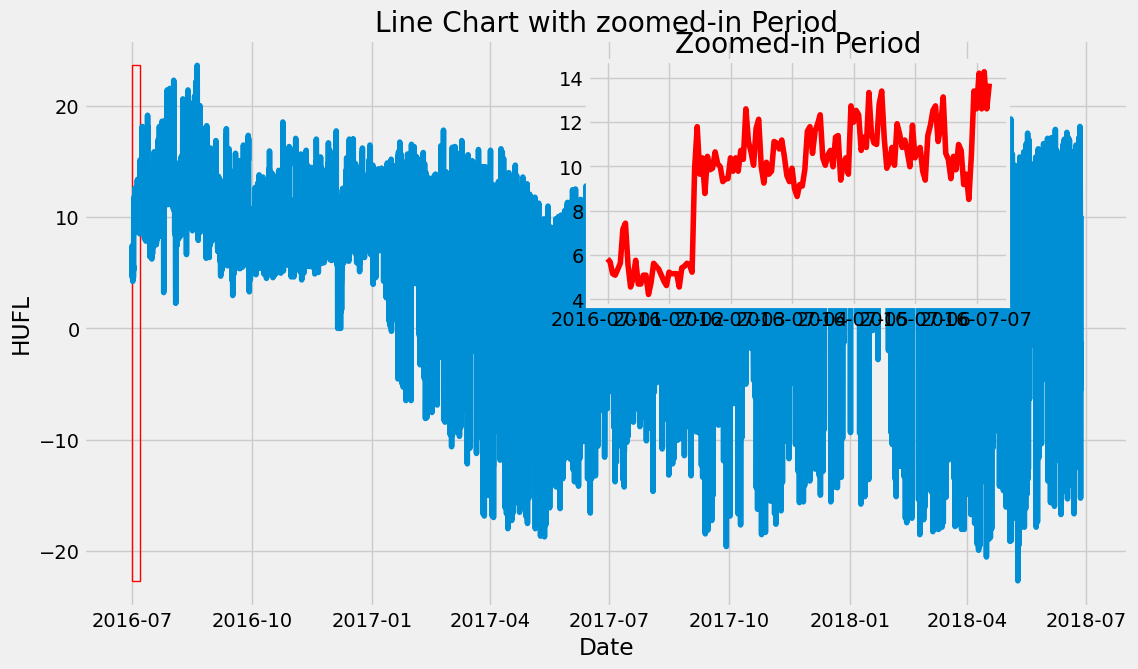

In [ ]:
# Line chart with zoomed-in-period
# selecting a time period time to zoom in on
start = 0
end = 150
# Creating the main line chart with a highlighted square
fig, ax = plt.subplots(figsize=(12, 7))
# Plotting the main line chart for a selected variable (example: 'HUFL')
ax.plot(df['date'], df['HUFL'], label='HUFL')
# Adding a rectangle to highlight the zoomed-in area
rect = plt.Rectangle((df['date'][start], min(df['HUFL'])),
                     df['date'][end] - df['date'][start],
                     max(df['HUFL']) - min(df['HUFL']),
                     linewidth = 1, edgecolor = 'r', facecolor = 'none')
ax.add_patch(rect)
# Creating an inset (zoomed-in) plot within the main plot
ax_inset = fig.add_axes([0.5, 0.5, 0.35, 0.35]) # [left, bottom, width, heigh]
ax_inset.plot(df['date'][start:end], df['HUFL'][start:end], color='r')
ax_inset.set_title('Zoomed-in Period')
# Setting labels and title for the main plot
ax.set_xlabel('Date')
ax.set_ylabel('HUFL')
ax.set_title('Line Chart with zoomed-in Period')
# Display the plot
plt.show()

####**<font color='blue'>Box Plots</font>**

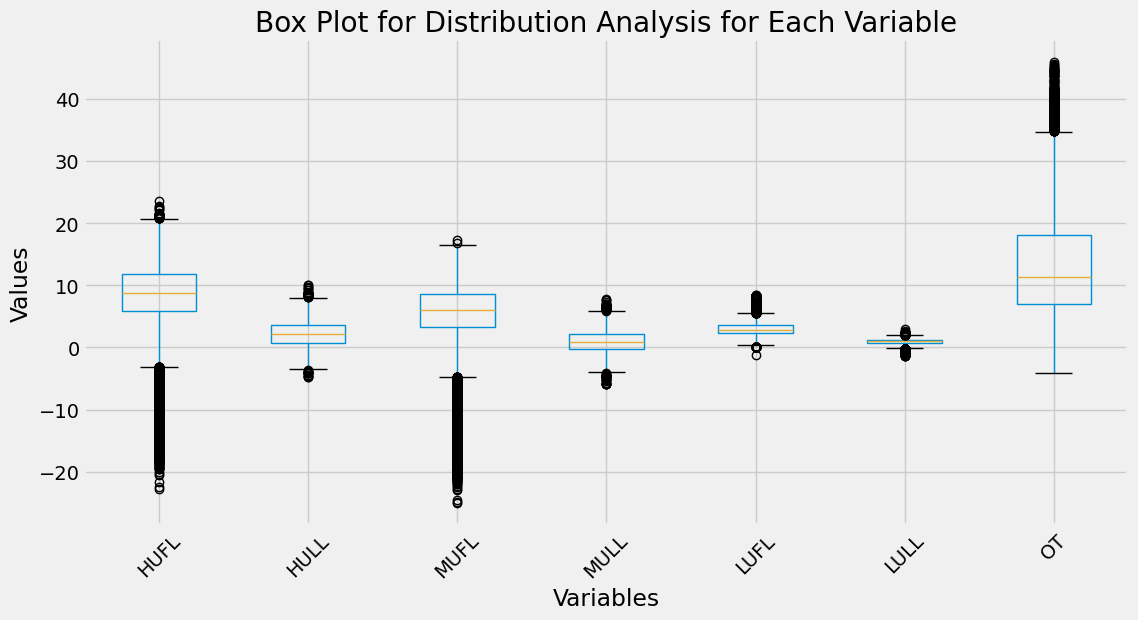

In [ ]:
# Creating Box Plots for Distribution Analysis of each variable
plt.figure(figsize=(12, 6))
df.boxplot(column = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'])
plt.xlabel('Variables')
plt.ylabel('Values')
plt.title('Box Plot for Distribution Analysis for Each Variable')
plt.xticks(rotation = 45)
plt.show()

In [ ]:
import plotly.express as px
fig = px.box(df, x = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'])
fig.show()

####**<font color='blue'>Bar Chart</font>**

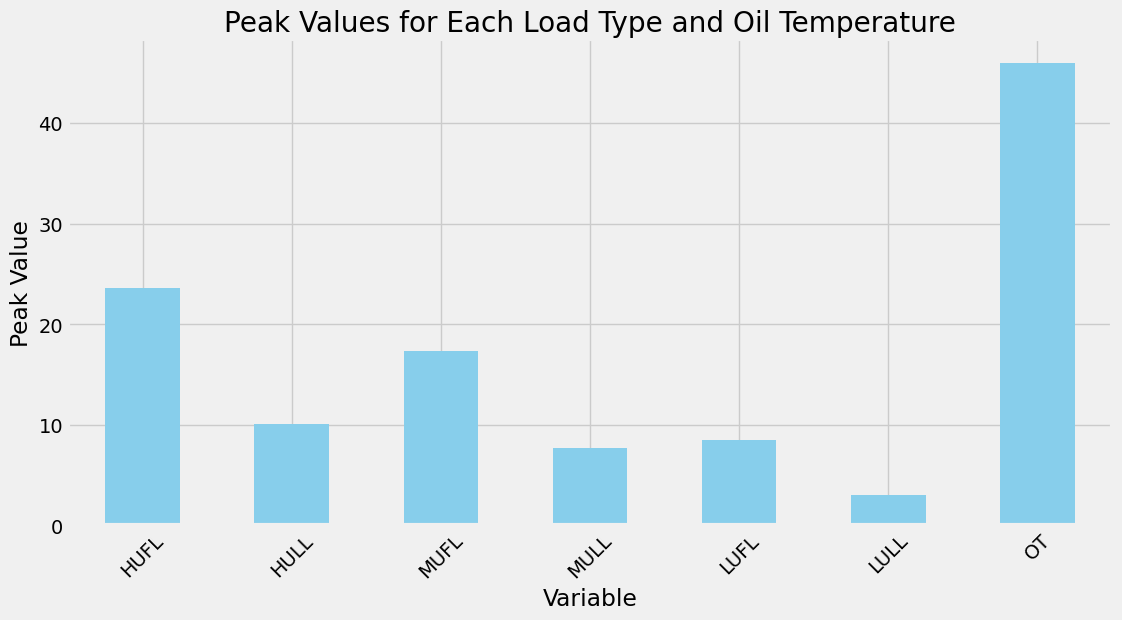

In [ ]:
# Indentifying peak values and their corresponding times for each column
peak_values = df.max()
peak_times = df.idxmax()

# Creating a DataFrame to display peak values and their times
peak_analysis = pd.DataFrame({'Peak Value': peak_values, 'Peak Time': peak_times})

# Dropping the 'date' column as it's not a load or temperature type
peak_analysis = peak_analysis.drop('date')

# Plotting the peak values for visual representation
plt.figure(figsize=(12, 6))
peak_analysis['Peak Value'].plot(kind='bar', color = 'skyblue')
plt.title('Peak Values for Each Load Type and Oil Temperature')
plt.xlabel('Variable')
plt.ylabel('Peak Value')
plt.xticks(rotation=45)
plt.show()

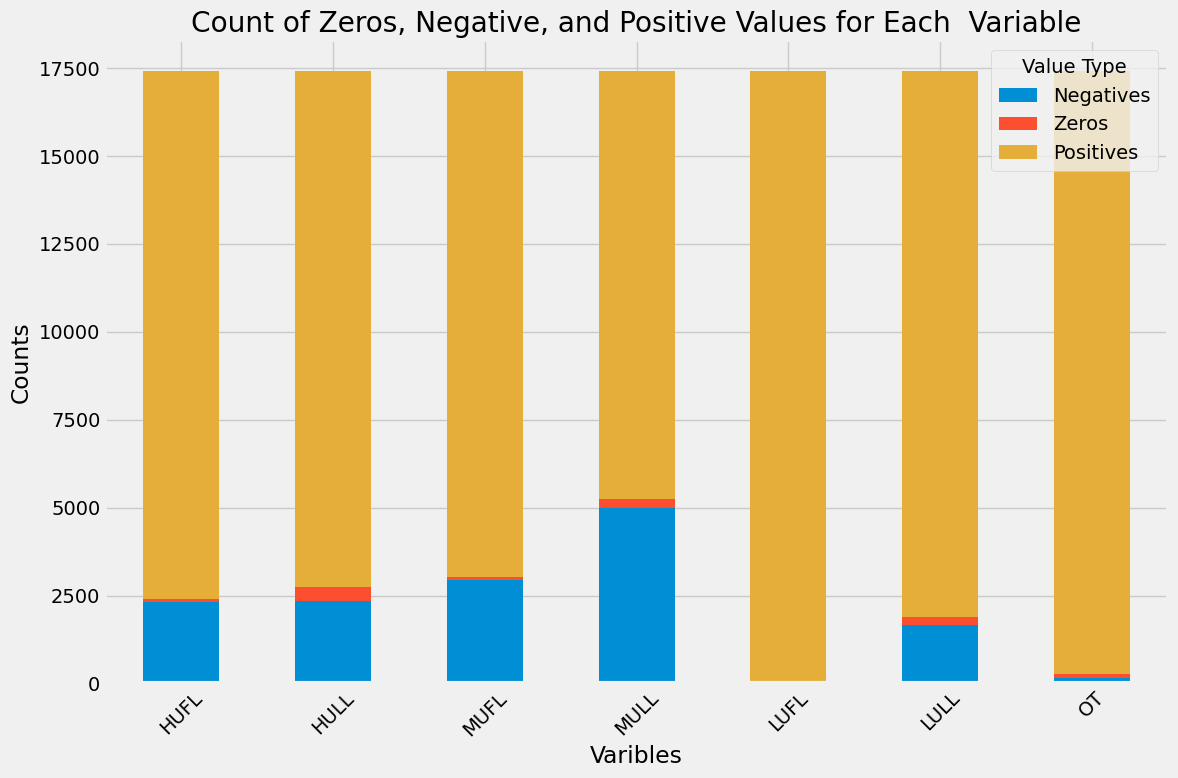

In [ ]:
# Preparing the data for the stacked bar chart to count zeros, negatives and positives
counts = {column: [
    np.sum(df[column] < 0),
    np.sum(df[column] == 0),
    np.sum(df[column] > 0)
] for column in df.columns[1:]}

# Creating a DataFrame from the counts dictionary
counts_df = pd.DataFrame(counts, index = ['Negatives', 'Zeros', 'Positives']).T

# Plotting the stacked bar chart
ax = counts_df.plot(kind = 'bar', stacked = True, figsize=(12, 8))
ax.set_title('Count of Zeros, Negative, and Positive Values for Each  Variable')
ax.set_xlabel('Varibles')
ax.set_ylabel('Counts')
plt.xticks(rotation=45)
plt.legend(title='Value Type')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

# Đếm số giá trị âm, bằng 0 và dương
counts = {
    column: [
        np.sum(df[column] < 0),
        np.sum(df[column] == 0),
        np.sum(df[column] > 0)
    ]
    for column in df.columns[1:]  # Bỏ qua cột date
}

# Tạo DataFrame dạng wide
counts_df = pd.DataFrame(
    counts,
    index=['Negatives', 'Zeros', 'Positives']
).T

# Đưa index thành cột Variable
counts_df = counts_df.reset_index()
counts_df = counts_df.rename(columns={'index': 'Variable'})

# Vẽ trực tiếp từ dữ liệu wide
fig = px.bar(
    counts_df,
    x='Variable',
    y=['Negatives', 'Zeros', 'Positives'],
    barmode='stack',
    title='Count of Negative, Zero, and Positive Values for Each Variable',
    labels={
        'Variable': 'Variables',
        'value': 'Counts',
        'variable': 'Value Type'
    }
)

fig.update_layout(
    width=1000,
    height=650,
    xaxis_tickangle=-45,
    legend_title_text='Value Type'
)

fig.show()

####**<font color='blue'>Donut Chart</font>**

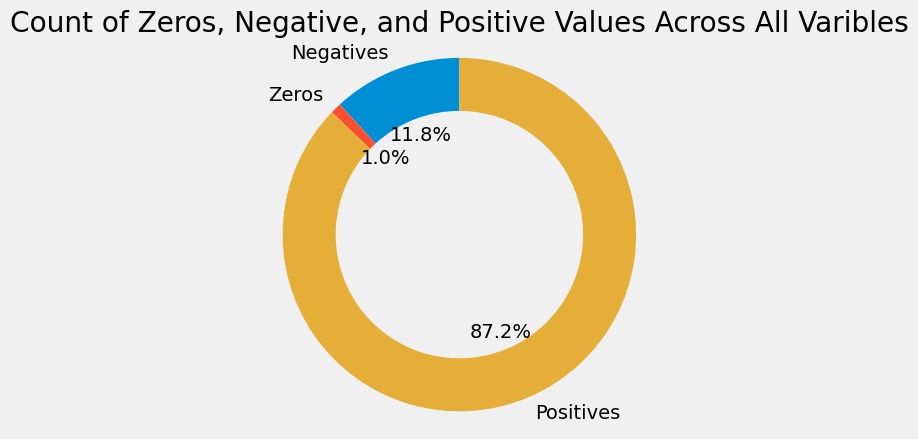

In [ ]:
# Preparing the data for the stacked bar chart to count zeros, negatives and positives
counts = {column: [
    np.sum(df[column] < 0),
    np.sum(df[column] == 0),
    np.sum(df[column] > 0)
] for column in df.columns[1:]}

# Creating a DataFrame from the counts dictionary
counts_df = pd.DataFrame(counts, index = ['Negatives', 'Zeros', 'Positives']).T

# Preparing data for the donut chart
counts_for_donut = counts_df.sum()

# Plotting the donut chart
fig, ax = plt.subplots()
ax.pie(counts_for_donut, labels=counts_for_donut.index, autopct='%.1f%%', startangle=90, wedgeprops=dict(width=0.3))

# Draw a circle at the center to create a donut hole
# centre_circle = plt.Circle((0, 0), 0.70, fc='white')
# fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')

plt.title('Count of Zeros, Negative, and Positive Values Across All Varibles')
plt.show()

####**<font color='blue'>Correlation Chart</font>**

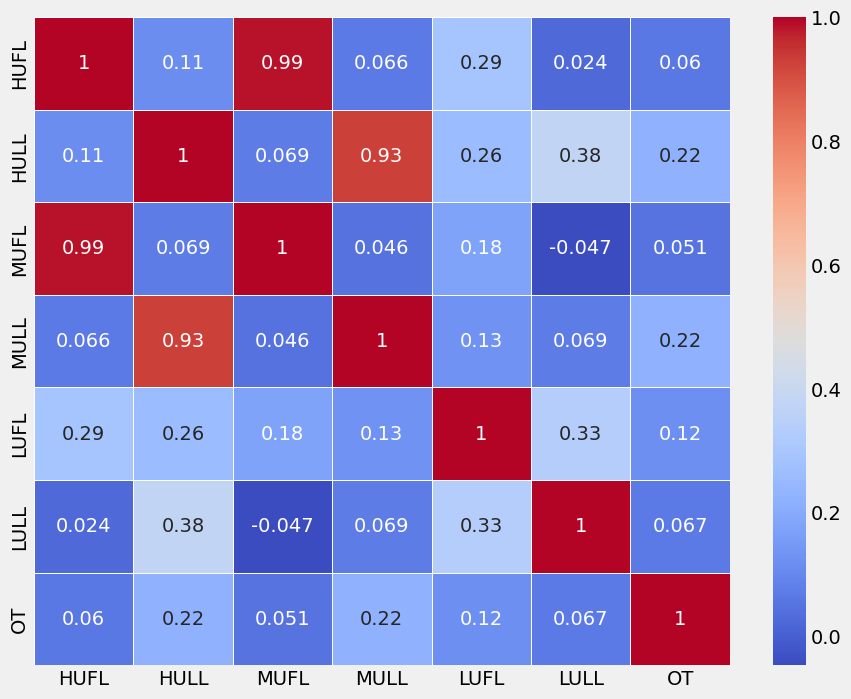

In [ ]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

####**<font color='blue'>Scatter Plot</font>**

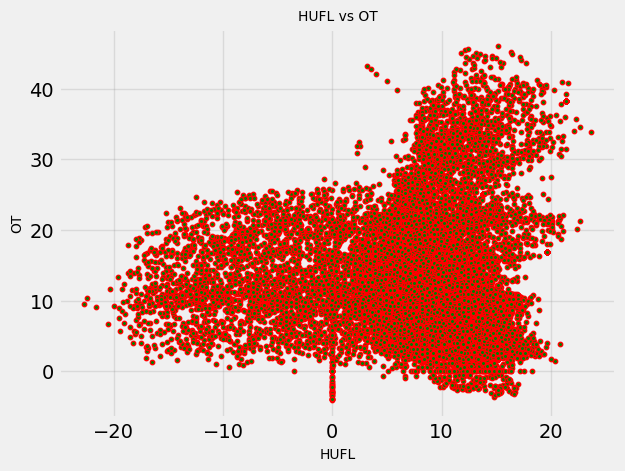

In [ ]:
plt.scatter(df.HUFL, df.OT, marker = 'o',
            color = 'green', linewidths= 1, edgecolors = "red", s = 10)
plt.style.use('fivethirtyeight')
plt.xlabel("HUFL", size = 10, color = 'black')
plt.ylabel("OT", size = 10, color = "black")
plt.title("HUFL vs OT", size = 10)
plt.xticks(color = "black")
plt.xticks(color = "black")
plt.grid(color = "grey", alpha = 0.2)
plt.show()

####**<font color='blue'>Pairplot</font>**

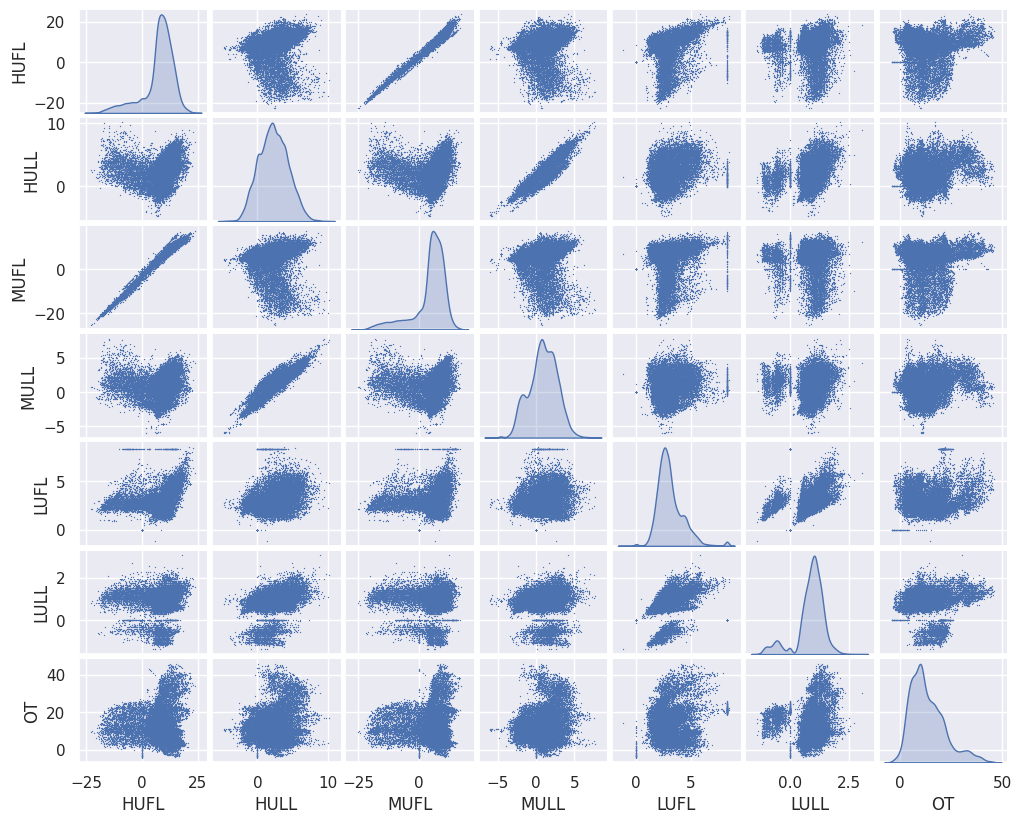

In [ ]:
# Setting the aesthetic style of the plots
sns.set(style="darkgrid")

# Creating the pair plot with custom settings
pair_plot = sns.pairplot(df,
                         diag_kind="kde", # Kernel density estimate for diagonal
                         markers="o",     # Custom marker style
                         plot_kws=dict(linewidth=0, s=0.9), # line width and size
                         diag_kws=dict(fill=True))  # Shade for KDE plots

pair_plot.fig.set_size_inches(10, 8)
# Enhancing asthetics with despine
sns.despine()

####**<font color='blue'>Pie Chart</font>**


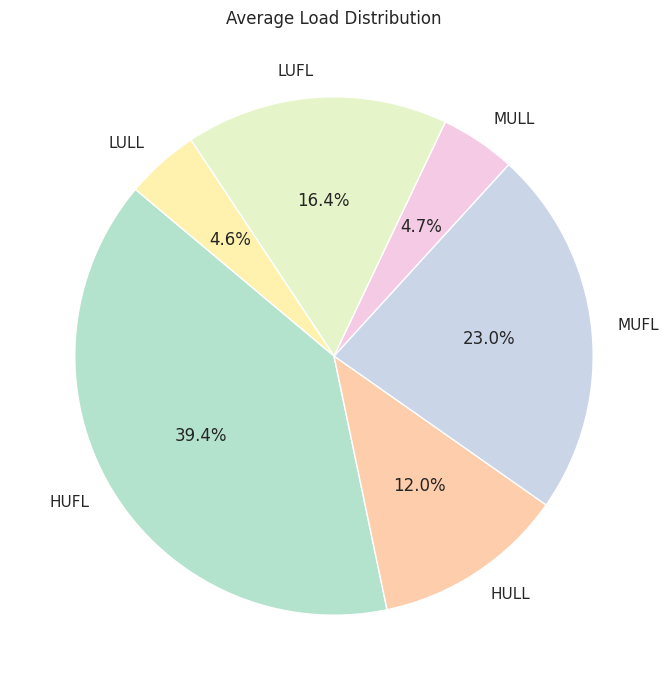

In [ ]:
# Calculating the average of each load type for the pie chart
average_loads = df[['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']].mean()

# Setting up the figure for the pie chart
plt.figure(figsize=(8, 8))

# Creating the pie chart
cmap_colors = plt.cm.Pastel2.colors
plt.pie(average_loads, labels=average_loads.index, autopct='%.1f%%', startangle=140, colors=cmap_colors)

# Adding a title
plt.title('Average Load Distribution')

# Display the plot
plt.show()

# **2. Student Performance Dataset**

## **<font color = 'blue'>Prepare and load dataset</font>**

https://www.kaggle.com/datasets/spscientist/students-performance-in-exams





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df_st = pd.read_csv("/content/StudentsPerformance.csv")
df_st

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
df_st.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


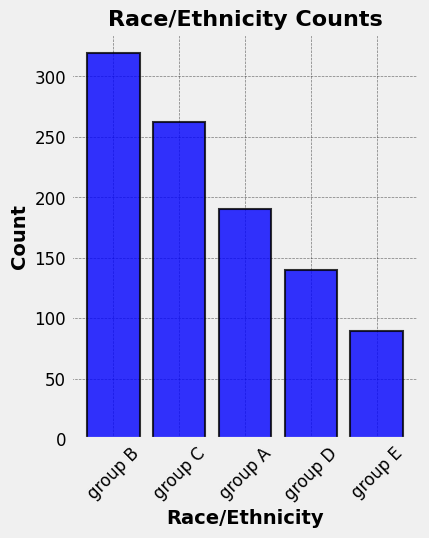

In [ ]:
# Bar Chart
fig = plt.figure(figsize=(4, 5))
plt.style.use('fivethirtyeight')
plt.bar(
    x = df_st["race/ethnicity"].unique(),
    height = df_st["race/ethnicity"].value_counts().to_list(),
    color = 'blue',         # Set the color of the bars
    edgecolor = 'black',    # Set the color of the bar edges
    linewidth = 1.5,        # Set the width of the bar edges
    alpha = 0.8             # Set the transparency of the bars
)

plt.xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')  # Set the x-axis label with font size and style
plt.ylabel('Count', fontsize=14, fontweight='bold')           # Set the y-axis label with font size and style
plt.title('Race/Ethnicity Counts', fontsize=16, fontweight='bold')  # Set the chart title with font size and style
plt.xticks(fontsize=12, rotation = 45)    # Set the font size of the x-axis tick labels
plt.yticks(fontsize=12)    # Set the font size of the y-axis tick labels
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color = "black")  # Display gridlines with a dashed style and reduced opacity

plt.show()

In [ ]:
grouped_data = df_st.groupby(['race/ethnicity', 'gender']).size().unstack()
grouped_data

gender,female,male
race/ethnicity,,
group A,36,53
group B,104,86
group C,180,139
group D,129,133
group E,69,71


## **<font color='blue'>Bar Chart</font>**

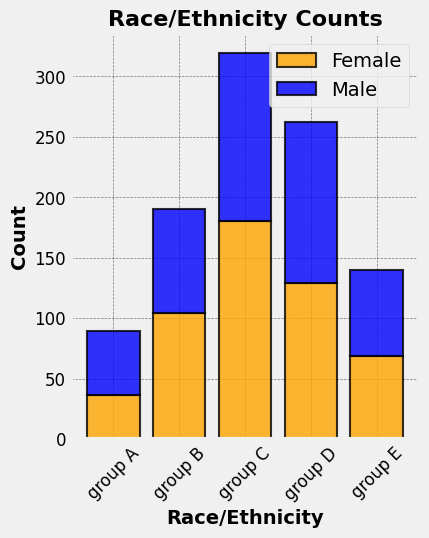

In [ ]:
# Bar Chart stacked
fig = plt.figure(figsize=(4, 5))
plt.style.use('fivethirtyeight')
plt.bar(
    x=grouped_data.index,
    height= grouped_data["female"],
    label = "Female",
    color='orange',      # Set the color of the bars
    edgecolor='black',    # Set the color of the bar edges
    linewidth=1.5,        # Set the width of the bar edges
    alpha=0.8             # Set the transparency of the bars
)

plt.bar(
    x=grouped_data.index,
    height= grouped_data["male"],
    bottom = grouped_data["female"],
    label = "Male",
    color='blue',      # Set the color of the bars
    edgecolor='black',    # Set the color of the bar edges
    linewidth=1.5,        # Set the width of the bar edges
    alpha=0.8             # Set the transparency of the bars
)

plt.xlabel('Race/Ethnicity', fontsize=14, fontweight='bold')  # Set the x-axis label with font size and style
plt.ylabel('Count', fontsize=14, fontweight='bold')           # Set the y-axis label with font size and style
plt.title('Race/Ethnicity Counts', fontsize=16, fontweight='bold')  # Set the chart title with font size and style
plt.xticks(fontsize=12, rotation = 45)    # Set the font size of the x-axis tick labels
plt.yticks(fontsize=12)    # Set the font size of the y-axis tick labels
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color = "black")# Display gridlines with a dashed style and reduced opacity
plt.legend()

plt.show()

## **<font color='blue'>Count Chart</font>**

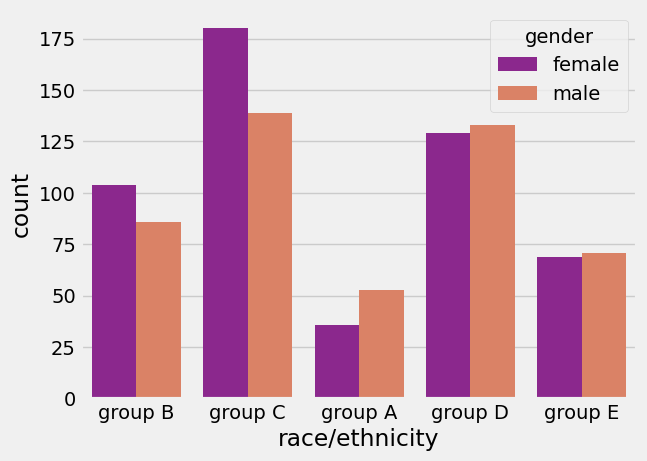

In [ ]:
# Seaborn
sns.countplot(data = df_st, x = 'race/ethnicity', hue = "gender", palette = "plasma")
plt.show()

# **3. Iris Dataset**

## **<font color = 'blue'>Prepare and load dataset</font>**

https://www.kaggle.com/datasets/saurabh00007/iriscsv

In [ ]:
iris = pd.read_csv("/content/Iris.csv")
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
iris.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## **<font color='blue'>Histogram</font>**

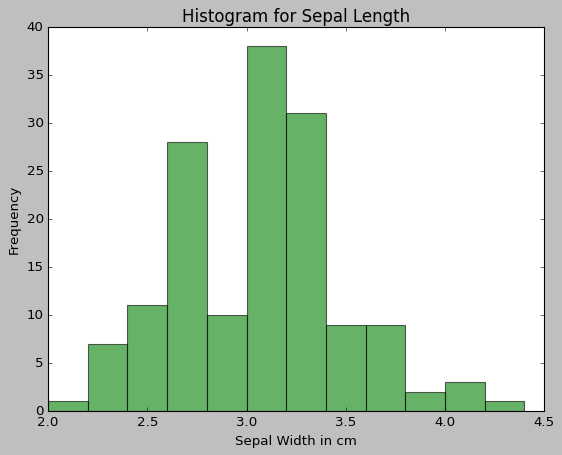

In [ ]:
# if bins of specific width are needed
bin_width = 0.2
bins = int((iris.SepalWidthCm.max() - iris.SepalWidthCm.min()) / bin_width) # Freedman-Diaconis
plt.style.use("classic")
plt.hist(iris.SepalWidthCm, bins = bins, color = 'green', alpha = 0.6,
         orientation = "vertical", rwidth = 1)
plt.xlabel("Sepal Width in cm", size = 12, color = "black")
plt.ylabel("Frequency", size = 12, color = "black")
plt.title("Histogram for Sepal Length", size =15, color = "black")
plt.xticks(color = "black")
plt.yticks(color = "black")
plt.show()

## **<font color='blue'>Scatter Plot</font>**

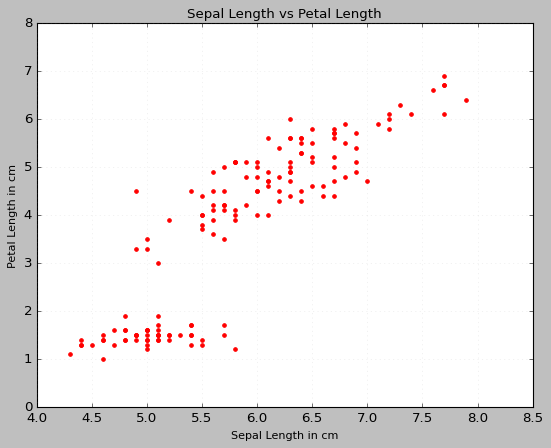

In [ ]:
# Using matplotlib

plt.scatter(iris.SepalLengthCm, iris.PetalLengthCm, marker = "o", color = "red", linewidths = 1, edgecolors = "red", s = 10)
plt.style.use('fivethirtyeight')
plt.xlabel("Sepal Length in cm", size = 10, color = "black")
plt.ylabel("Petal Length in cm", size = 10, color = "black")
plt.title("Sepal Length vs Petal Length", size =12, color = "black")
plt.xticks(color = "black")
plt.yticks(color = "black")
plt.grid(color = "grey", alpha = 0.2)
plt.show()

## **<font color='blue'>Bubble Chart</font>**

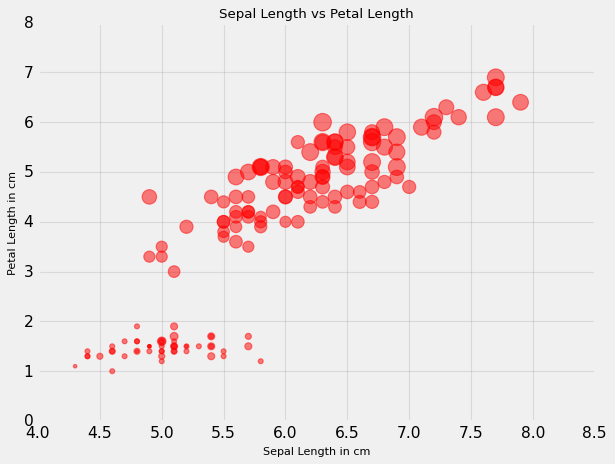

In [ ]:
from sklearn.preprocessing import MinMaxScaler

sizes = iris['PetalWidthCm']/iris['PetalWidthCm'].max() # Max Normalization

# Here, the size of the bubble will show the Petal Width

plt.figure()
plt.scatter(iris.SepalLengthCm, iris.PetalLengthCm, marker = "o",
            color = "red", linewidths = 1, edgecolors = "red",
            s= sizes*250, alpha = 0.5)
plt.style.use('fivethirtyeight')
plt.xlabel("Sepal Length in cm", size = 10, color = "black")
plt.ylabel("Petal Length in cm", size = 10, color = "black")
plt.title("Sepal Length vs Petal Length", size =12, color = "black")
plt.xticks(color = "black")
plt.yticks(color = "black")
plt.grid(color = "grey", alpha = 0.2)
plt.show()

In [ ]:
import plotly.express as px
fig = px.scatter(iris, x = "SepalLengthCm", y = "PetalLengthCm", color = "Species",
                 size = sizes, hover_data = ['PetalWidthCm'])
fig.show()

## **<font color='blue'>KDE Chart</font>**

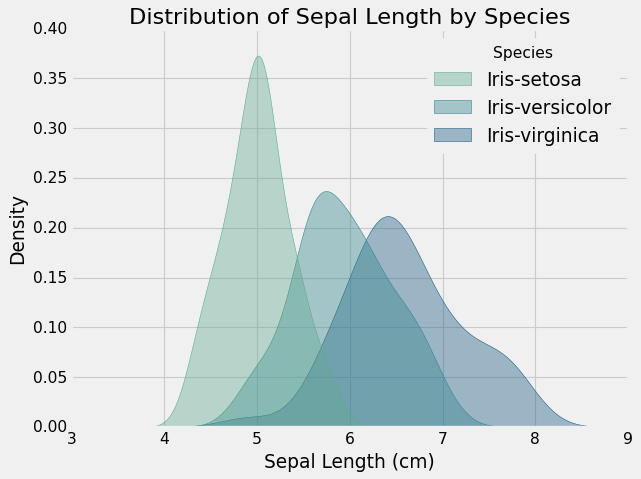

In [ ]:
sns.kdeplot(x = iris["SepalLengthCm"], hue = iris["Species"],
            linewidth = 0.5, fill = True, multiple = "layer",
            palette = "crest", alpha = 0.4)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Density")
plt.title("Distribution of Sepal Length by Species")
plt.show()

## **<font color='blue'>Displot </font>**

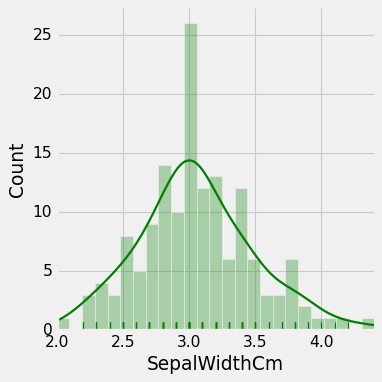

In [ ]:
sns.displot(iris["SepalWidthCm"], bins = 25, kde = True,
            rug = True, color = "green", alpha = 0.3,
            line_kws = {'linewidth': 2})
plt.show()

## **<font color='blue'>Pairplot</font>**

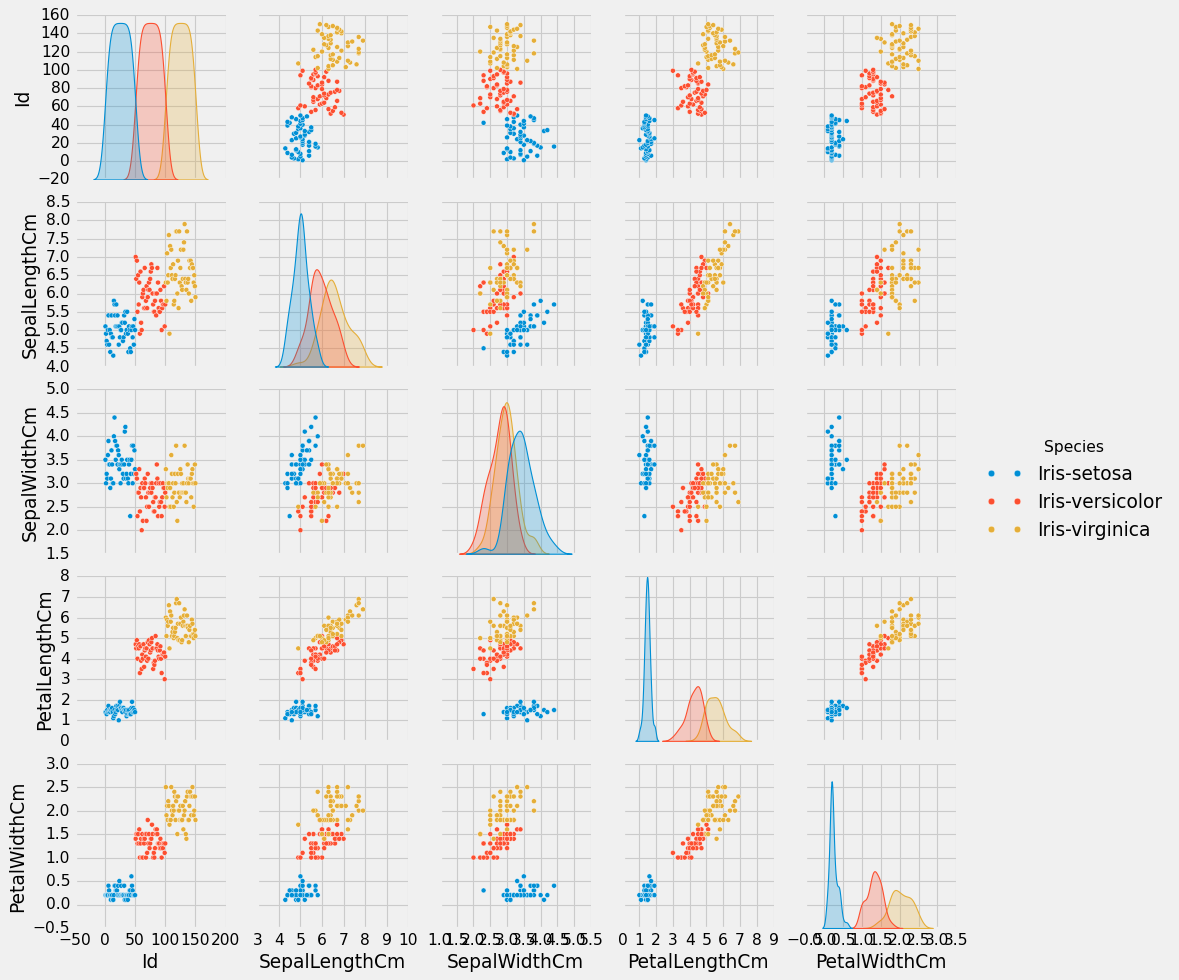

In [ ]:
sns.pairplot(data = iris, hue = "Species", corner = False,
             diag_kws = {"linewidth": 1, "fill": True},
             plot_kws = dict(marker = "o"))

## **<font color='blue'>3D Visualization</font>**

Text(0.5, 0, 'PetalLength in cm')

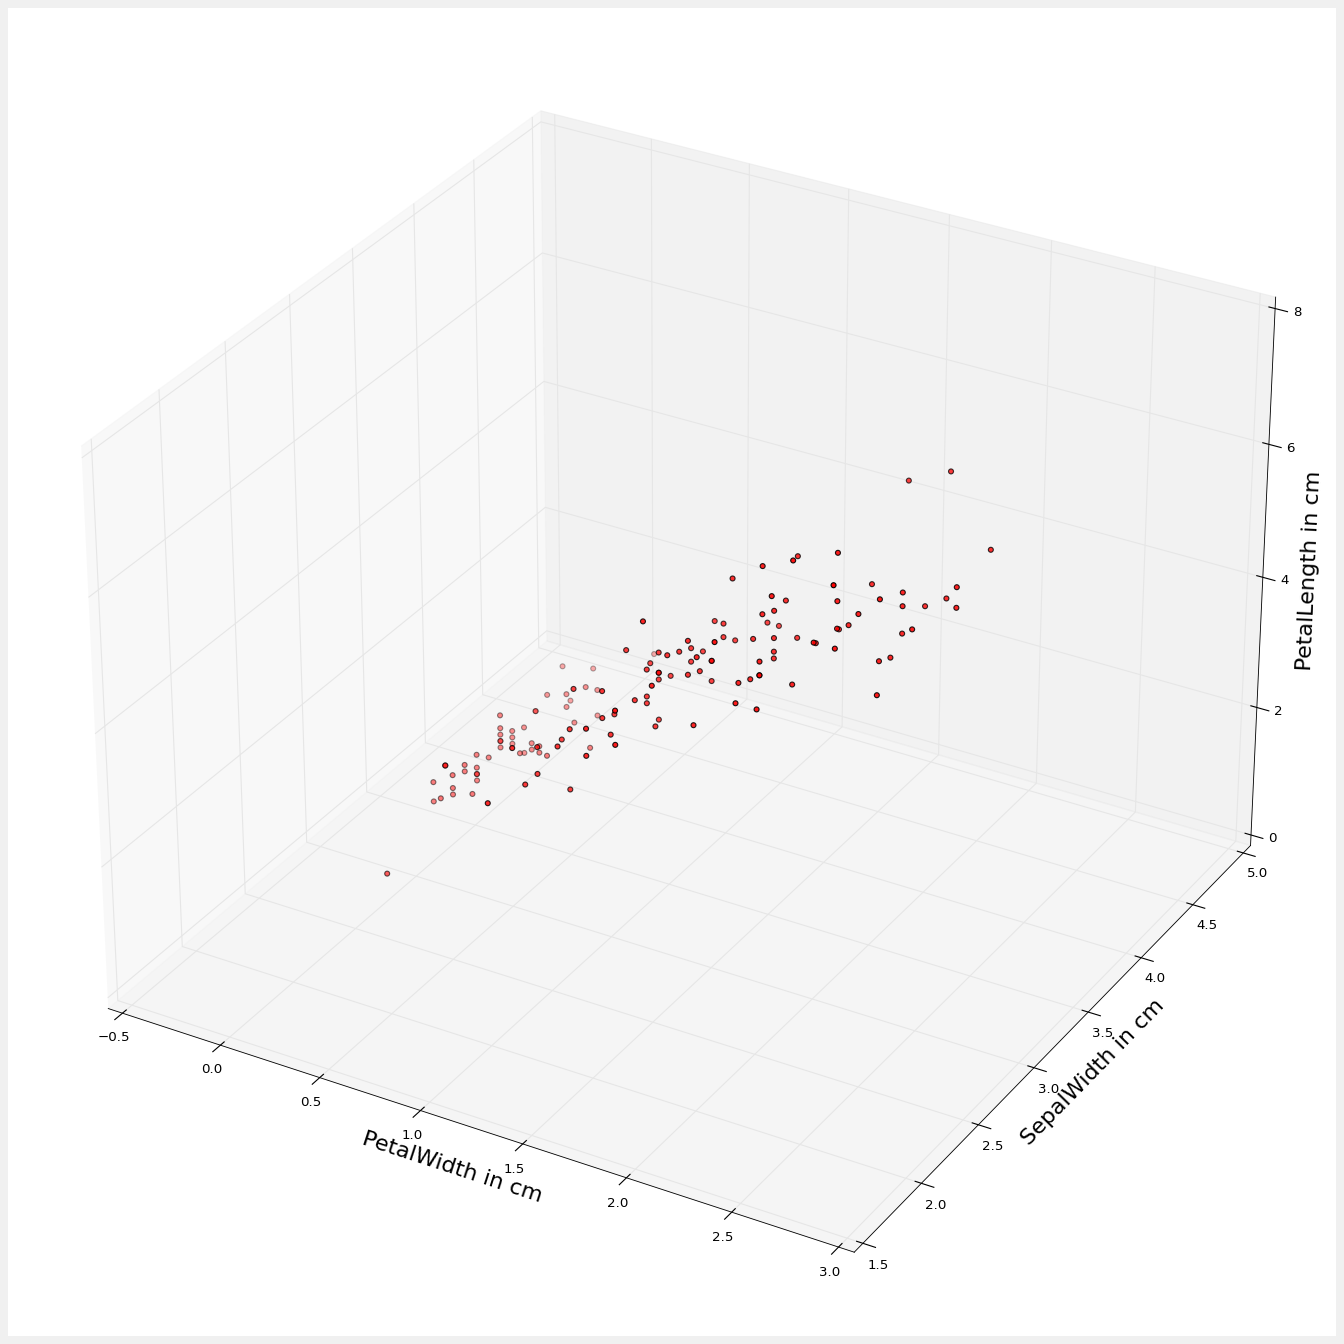

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize = (20,20))
plt.style.use("classic")
ax = fig.add_subplot(111, projection='3d')
ax.scatter(iris["PetalWidthCm"], iris["SepalWidthCm"],iris["PetalLengthCm"], c = "red")
ax.set_xlabel("PetalWidth in cm", fontsize = 20)
ax.set_ylabel("SepalWidth in cm", fontsize = 20)
ax.set_zlabel("PetalLength in cm", fontsize = 20)

## **4. Other Chart: Word Cloud**

In [ ]:
import pandas as pd

df_fs = pd.read_csv("/content/five_star_reviews.csv")

df_fs.head()

,Rating,Review
0,5,"You have to improve the camera performance, an..."
1,5,It keeps hanging up completely phone(S10+) and...
2,5,Perfect for virtual conversation. We suggest t...
3,5,A very decent experience i've gained using the...
4,5,This app is very good as everyone knows. Here ...


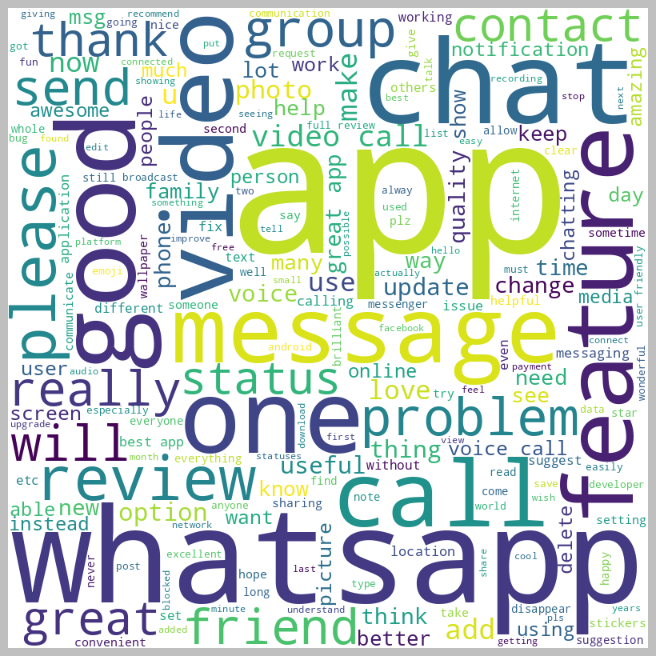

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

stopwords = set(STOPWORDS)
words = ''
for review in df_fs.Review:
    tokens = str(review).split()
    tokens = [i.lower() for i in tokens]
    words += ' '.join(tokens) + ' '

wordcloud = WordCloud(width = 800, height = 800,
                      background_color = 'white',
                      stopwords = stopwords,
                      min_font_size = 10).generate(words)

# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

In [ ]:
df_os = pd.read_csv("/content/one_star_reviews.csv")
df_os.head()

,Rating,Review
0,1,Latest update broke the photo taking function....
1,1,It was one of my favourite app. Easy and secur...
2,1,WhatsApp has a major glitch or bug that is hor...
3,1,It was a good app for communication but it is ...
4,1,A almost a year passed and the bug I reported ...


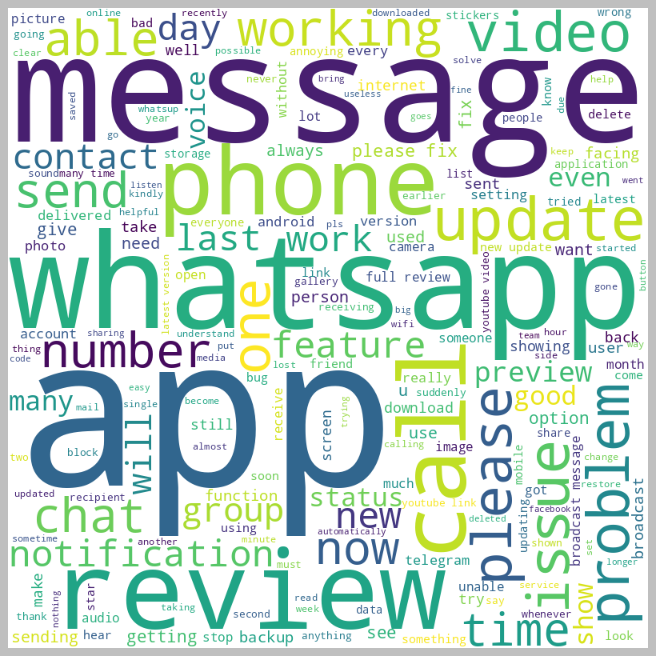

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

stopwords = set(STOPWORDS)
words = ''
for review in df_os.Review:
    tokens = str(review).split()
    tokens = [i.lower() for i in tokens]
    words += ' '.join(tokens) + ' '

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(words)

# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

# **5. Case Study: Uber Trips Analysis**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("/content/uber-raw-data-sep14.csv")
data["Date/Time"] = data["Date/Time"].map(pd.to_datetime)
data.head()

,Date/Time,Lat,Lon,Base
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512


In [ ]:
data["Day"] = data["Date/Time"].apply(lambda x: x.day)
data["Weekday"] = data["Date/Time"].apply(lambda x: x.weekday())
data["Hour"] = data["Date/Time"].apply(lambda x: x.hour)
print(data.head())

In [ ]:
sns.set(rc={'figure.figsize':(12, 10)})
sns.distplot(data["Day"])

In [ ]:
sns.distplot(data["Hour"])

In [ ]:
sns.distplot(data["Weekday"])

In [ ]:
# Correlation of Weekday and Hour
df = data.groupby(["Weekday", "Hour"]).apply(lambda x: len(x))
df = df.unstack()
sns.heatmap(df, annot=False)

In [ ]:
data.plot(kind='scatter', x='Lon', y='Lat', alpha=0.4, s=data['Day'], label='Uber Trips',
figsize=(12, 8), cmap=plt.get_cmap('jet'))
plt.title("Uber Trips Analysis")
plt.legend()
plt.show()